# BPP vs Reasoning Accuracy plots (multi-seed averaged)

Reads `*_paroquant_reasoning(_seed<N>)?/{AIME-2024,AIME-2025,GPQA-Diamond}.jsonl` (lighteval output) and `lmbda<N>_result.json` (our compression bpp). Per `(model, config, dataset)` we collect accuracy from every seed directory (seed=42 lives in `*_paroquant_reasoning/`, seed=43 in `*_paroquant_reasoning_seed43/`, etc.) and report **mean ± std across seeds**.

Tasks: **AIME-2024 (30), AIME-2025 (30), GPQA-Diamond (198)**, plus their simple mean as `reasoning_avg`.

Methods covered (default config):
- `Ours` — `hf_model_comp_results_v2/<model>/ql_ldlq128_rnorm_ft/`
- `QTIP` — `hf_model_comp_results_v2/qtip/<model_key>/ft1/`
- `Base model` (BF16) — `hf_model_comp_results_v2/<model>/baseline_paroquant_reasoning(_seed<N>)?/`

In [10]:
import os
import json
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import make_interp_spline

## Loaders

In [11]:
RESULTS_V2 = '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2'
QTIP_RESULTS = '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip'

DATASETS = ['AIME-2024', 'AIME-2025', 'GPQA-Diamond']
EXTRA_DATASETS = ['MMLU-PRO']


def _parse_metrics(m):
    if isinstance(m, dict):
        return m
    if isinstance(m, str):
        return json.loads(m.replace("'", '"'))
    return {}


def load_extractive_match(jsonl_path):
    try:
        data = json.load(open(jsonl_path))
    except Exception as e:
        print(f'  read fail: {jsonl_path}: {e}')
        return None
    if not isinstance(data, list) or not data:
        return None
    s = 0.0
    for it in data:
        try:
            s += _parse_metrics(it.get('metrics', {})).get('extractive_match', 0)
        except Exception:
            pass
    return s / len(data)


def _bpp_from_result_json(result_json_path):
    if not os.path.exists(result_json_path):
        return None
    try:
        d = json.load(open(result_json_path))
    except Exception:
        return None
    for k in ('bpp_loss_with_metadata', 'bpp_loss', 'bpp_with_metadata', 'bpp'):
        v = d.get(k)
        if isinstance(v, (int, float)) and v > 0:
            return float(v)
    return None


def _load_longbench_avg(base_dir, tag):
    """Load LongBench V1 average from *_longbenchV1/longbenchV1.json.
    Returns value in [0, 1] (longbenchV1.json stores 0-100 scale)."""
    result_path = os.path.join(base_dir, f'{tag}_longbenchV1', 'longbenchV1.json')
    if not os.path.exists(result_path):
        return None
    try:
        d = json.load(open(result_path))
    except Exception:
        return None
    avg = d.get('_avg')
    if avg is not None:
        return float(avg) / 100.0
    scores = [v for k, v in d.items()
              if not k.startswith('_') and isinstance(v, (int, float))]
    return float(np.mean(scores)) / 100.0 if scores else None


def _find_seed_dirs(base_dir, tag):
    out = []
    canonical = os.path.join(base_dir, f'{tag}_paroquant_reasoning')
    if os.path.isdir(canonical):
        out.append(('seed42', canonical))
    pattern = re.compile(rf'^{re.escape(tag)}_paroquant_reasoning_seed(\d+)$')
    for entry in sorted(os.listdir(base_dir)):
        full = os.path.join(base_dir, entry)
        if not os.path.isdir(full):
            continue
        m = pattern.match(entry)
        if m:
            out.append((f'seed{m.group(1)}', full))
    return out


def collect_paroquant_dir(model_label, exp_label, base_dir, key_kind):
    if not os.path.isdir(base_dir):
        print(f'  missing dir: {base_dir}')
        return []
    rows = []
    seen_tags = set()

    tag_pattern = re.compile(r'^(.+)_paroquant_reasoning(_seed\d+)?$')
    lb_pattern = re.compile(r'^(.+)_longbenchV1$')
    for entry in sorted(os.listdir(base_dir)):
        full = os.path.join(base_dir, entry)
        if not os.path.isdir(full):
            continue
        m = tag_pattern.match(entry)
        if m:
            seen_tags.add(m.group(1))
        m = lb_pattern.match(entry)
        if m:
            seen_tags.add(m.group(1))

    for tag in sorted(seen_tags):
        if key_kind == 'lmbda':
            m = re.match(r'lmbda(\d+(\.\d+)?)$', tag)
            if not m:
                continue
            key = float(m.group(1))
            bpp = _bpp_from_result_json(os.path.join(base_dir, f'{tag}_result.json'))
        elif key_kind == 'bit':
            m = re.match(r'(\d+)bit$', tag)
            if not m:
                continue
            key = int(m.group(1))
            bpp = float(key)
        elif key_kind == 'baseline':
            if tag != 'baseline':
                continue
            key = 'BF16'
            bpp = 16.0
        else:
            continue

        seed_dirs = _find_seed_dirs(base_dir, tag)
        row = {
            'Model': model_label, 'Experiment': exp_label,
            'tag': tag, 'key': key, 'bpp': bpp,
            'n_seeds': len(seed_dirs),
            'seeds': ','.join(s for s, _ in seed_dirs),
        }

        avg_scores = []
        for ds in DATASETS:
            seed_accs = []
            for _, sd in seed_dirs:
                jp = os.path.join(sd, f'{ds}.jsonl')
                if os.path.exists(jp):
                    a = load_extractive_match(jp)
                    if a is not None:
                        seed_accs.append(a)
            if seed_accs:
                row[ds] = float(np.mean(seed_accs))
                row[f'{ds}_std'] = float(np.std(seed_accs, ddof=0)) if len(seed_accs) > 1 else 0.0
                row[f'{ds}_n'] = len(seed_accs)
                avg_scores.append(row[ds])
            else:
                row[ds] = None; row[f'{ds}_std'] = None; row[f'{ds}_n'] = 0
        row['reasoning_avg'] = float(np.mean(avg_scores)) if avg_scores else None

        for ds in EXTRA_DATASETS:
            seed_accs = []
            for _, sd in seed_dirs:
                jp = os.path.join(sd, f'{ds}.jsonl')
                if os.path.exists(jp):
                    a = load_extractive_match(jp)
                    if a is not None:
                        seed_accs.append(a)
            if seed_accs:
                row[ds] = float(np.mean(seed_accs))
                row[f'{ds}_std'] = float(np.std(seed_accs, ddof=0)) if len(seed_accs) > 1 else 0.0
                row[f'{ds}_n'] = len(seed_accs)
            else:
                row[ds] = None; row[f'{ds}_std'] = None; row[f'{ds}_n'] = 0

        # LongBench V1 — from *_longbenchV1/longbenchV1.json (0-1 scale)
        lb_avg = _load_longbench_avg(base_dir, tag)
        row['LongBench-V1'] = lb_avg
        row['LongBench-V1_std'] = 0.0

        rows.append(row)
    return rows


def build_dataframe(sources):
    all_rows = []
    for s in sources:
        rs = collect_paroquant_dir(s['model_label'], s['exp_label'], s['base_dir'], s['key_kind'])
        all_rows.extend(rs)
    return pd.DataFrame(all_rows)

## Load all results

In [12]:
sources = [
    # Qwen3-4B
    {
        'model_label': 'Qwen3-4B',
        'exp_label': 'Ours',
        'base_dir': f'{RESULTS_V2}/Qwen--Qwen3-4B/ql_ldlq128_rnorm_ft',
        'key_kind': 'lmbda',
    },
    {
        'model_label': 'Qwen3-4B',
        'exp_label': 'QTIP',
        'base_dir': f'{QTIP_RESULTS}/qwen3_4b/ft1',
        'key_kind': 'bit',
    },
    {
        'model_label': 'Qwen3-4B',
        'exp_label': 'Base model',
        'base_dir': f'{RESULTS_V2}/Qwen--Qwen3-4B',
        'key_kind': 'baseline',
    },
    # Qwen3-8B
    {
        'model_label': 'Qwen3-8B',
        'exp_label': 'Ours',
        'base_dir': f'{RESULTS_V2}/Qwen--Qwen3-8B/ql_ldlq128_rnorm_ft',
        'key_kind': 'lmbda',
    },
    {
        'model_label': 'Qwen3-8B',
        'exp_label': 'QTIP',
        'base_dir': f'{QTIP_RESULTS}/qwen3_8b/ft1',
        'key_kind': 'bit',
    },
    {
        'model_label': 'Qwen3-8B',
        'exp_label': 'Base model',
        'base_dir': f'{RESULTS_V2}/Qwen--Qwen3-8B',
        'key_kind': 'baseline',
    },
]
df = build_dataframe(sources)
df = df.sort_values(['Model', 'Experiment', 'bpp']).reset_index(drop=True)
df

,Model,Experiment,tag,key,bpp,n_seeds,seeds,AIME-2024,AIME-2024_std,AIME-2024_n,...,AIME-2025_n,GPQA-Diamond,GPQA-Diamond_std,GPQA-Diamond_n,reasoning_avg,MMLU-PRO,MMLU-PRO_std,MMLU-PRO_n,LongBench-V1,LongBench-V1_std
0,Qwen3-4B,Base model,baseline,BF16,16.000000,1,seed42,0.733333,0.000000,1,...,1,0.540404,0.000000,1,0.624579,0.6875,0.0,1,None,0.0
1,Qwen3-4B,Ours,lmbda50,50.0,2.662192,3,"seed42,seed43,seed44",0.444444,0.041574,3,...,3,0.446128,0.015612,3,0.411672,0.6025,0.0,1,None,0.0
2,Qwen3-4B,Ours,lmbda100,100.0,3.160042,3,"seed42,seed43,seed44",0.511111,0.041574,3,...,3,0.498316,0.031495,3,0.503143,0.6480,0.0,1,None,0.0
3,Qwen3-4B,Ours,lmbda300,300.0,3.948022,3,"seed42,seed43,seed44",0.744444,0.015713,3,...,3,0.531987,0.012598,3,0.636588,0.6830,0.0,1,None,0.0
4,Qwen3-4B,Ours,lmbda1000,1000.0,4.772930,3,"seed42,seed43,seed44",0.711111,0.041574,3,...,3,0.547138,0.012598,3,0.619416,0.6855,0.0,1,None,0.0
5,Qwen3-4B,Ours,lmbda10000,10000.0,5.979113,3,"seed42,seed43,seed44",0.633333,0.027217,3,...,3,0.528620,0.014482,3,0.591021,0.6850,0.0,1,None,0.0
6,Qwen3-4B,Ours,lmbda30,30.0,NaN,1,seed42,NaN,NaN,0,...,0,NaN,NaN,0,NaN,NaN,NaN,0,None,0.0
7,Qwen3-4B,QTIP,2bit,2,2.000000,3,"seed42,seed43,seed44",0.066667,0.027217,3,...,3,0.329966,0.027457,3,0.154433,0.4560,0.0,1,None,0.0
8,Qwen3-4B,QTIP,3bit,3,3.000000,3,"seed42,seed43,seed44",0.555556,0.056656,3,...,3,0.516835,0.016666,3,0.501908,0.6460,0.0,1,None,0.0
9,Qwen3-4B,QTIP,4bit,4,4.000000,3,"seed42,seed43,seed44",0.744444,0.041574,3,...,3,0.548822,0.038316,3,0.638496,0.6755,0.0,1,None,0.0


## Plot helper (matches plot_bpp_acc_v5_csv style)

In [13]:
def _replace_none_with_nan(x):
    if hasattr(x, 'tolist'):
        x = x.tolist()
    return np.array([np.nan if v is None else v for v in x], dtype=float)


METRICS = [
    ('AIME-2024', 'AIME 2024'),
    ('AIME-2025', 'AIME 2025'),
    ('GPQA-Diamond', 'GPQA Diamond'),
    ('reasoning_avg', 'Reasoning Avg.'),
    ('MMLU-PRO', 'MMLU-Pro (2k)'),
    ('LongBench-V1', 'LongBench V1'),
]


def plot_reasoning_bpp(
    df_master,
    exp_names,
    models,
    plot_labels=None,
    zoom_ranges=None,
    ylim_settings=None,
    fp16_label='Base model',
    show_title=False,
    show_legend=True,
    metrics=METRICS,
    output_dir='plots_figures',
    save=True,
    error_bar=True,
):
    if plot_labels is None:
        plot_labels = exp_names
    if zoom_ranges is None:
        zoom_ranges = {}
    if ylim_settings is None:
        ylim_settings = {}

    plt.rcParams['font.size'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 19
    plt.rcParams['figure.titlesize'] = 22

    os.makedirs(output_dir, exist_ok=True)

    cmap = cm.get_cmap('tab10')
    colors = {}
    idx = 1
    for name in plot_labels:
        if 'Ours' in name:
            colors[name] = cmap(0)
        else:
            colors[name] = cmap(idx)
            idx += 1

    for m_name in models:
        df_model = df_master[df_master['Model'] == m_name]
        if df_model.empty:
            print(f'skip model {m_name}: no data')
            continue

        for metric_key, title in metrics:
            fig, ax = plt.subplots(figsize=(8, 6))
            current_zoom = zoom_ranges.get(metric_key, (1.8, 7.0))

            for k, label in zip(exp_names, plot_labels):
                df_e = df_model[df_model['Experiment'] == k]
                if df_e.empty or metric_key not in df_e.columns:
                    continue
                bpps = _replace_none_with_nan(df_e['bpp'].values)
                ys = _replace_none_with_nan(df_e[metric_key].values) * 100
                mask = (~np.isnan(bpps)) & (~np.isnan(ys))
                if not mask.any():
                    continue
                bb = bpps[mask]
                yy = ys[mask]
                std_col = f'{metric_key}_std'
                if error_bar and std_col in df_e.columns:
                    yerr = _replace_none_with_nan(df_e[std_col].values)[mask] * 100
                    if np.all(yerr == 0):
                        yerr = None
                else:
                    yerr = None
                order = np.argsort(bb)
                bb, yy = bb[order], yy[order]
                if yerr is not None:
                    yerr = yerr[order]
                ax.errorbar(bb, yy, yerr=yerr, marker='o', markersize=8,
                            capsize=4, label=label,
                            color=colors.get(label, 'gray'), linewidth=2)

            # BF16 horizontal reference
            df_fp = df_model[df_model['Experiment'] == fp16_label]
            if not df_fp.empty and metric_key in df_fp.columns:
                ys_fp = _replace_none_with_nan(df_fp[metric_key].values) * 100
                vals = ys_fp[~np.isnan(ys_fp)]
                if vals.size:
                    ref = float(vals[0])
                    ax.axhline(y=ref, linestyle='--', color='gray', linewidth=1.5,
                               label=f'{fp16_label} ({ref:.1f}%)')

            ax.set_xlim(current_zoom)
            if m_name in ylim_settings and metric_key in ylim_settings[m_name]:
                ax.set_ylim(ylim_settings[m_name][metric_key])
            ax.set_xlabel('Bits per parameter')
            ax.set_ylabel(f'{title} accuracy (%)')
            if show_title:
                ax.set_title(f'{m_name} — {title}')
            ax.grid(True, alpha=0.3)
            if show_legend:
                ax.legend(loc='lower right')
            plt.tight_layout()
            if save:
                fname = f'{output_dir}/{m_name}_{metric_key.replace("-","_")}.pdf'
                fig.savefig(fname, bbox_inches='tight')
                print(f'  saved {fname}')
            plt.show()
            plt.close(fig)

## Plot all metrics for both models

/tmp/ipykernel_1297034/3277205135.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


  saved plots_figures/Qwen3-4B_AIME_2024.pdf


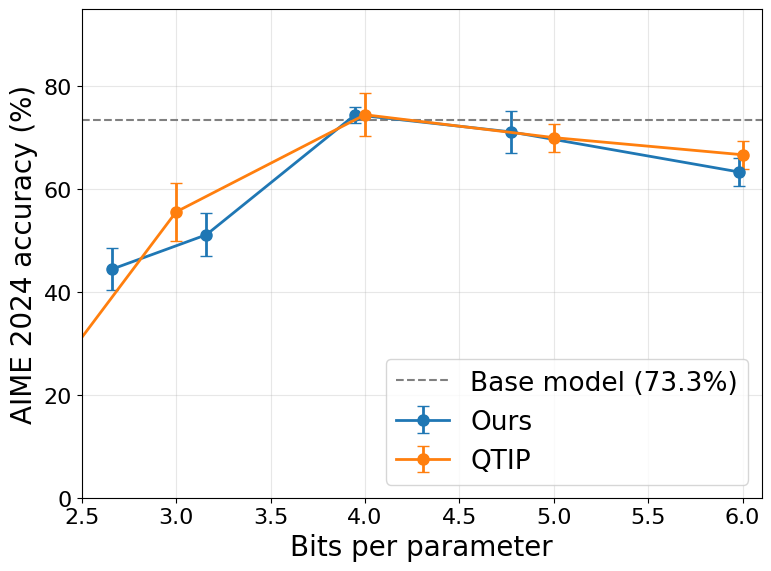

  saved plots_figures/Qwen3-4B_AIME_2025.pdf


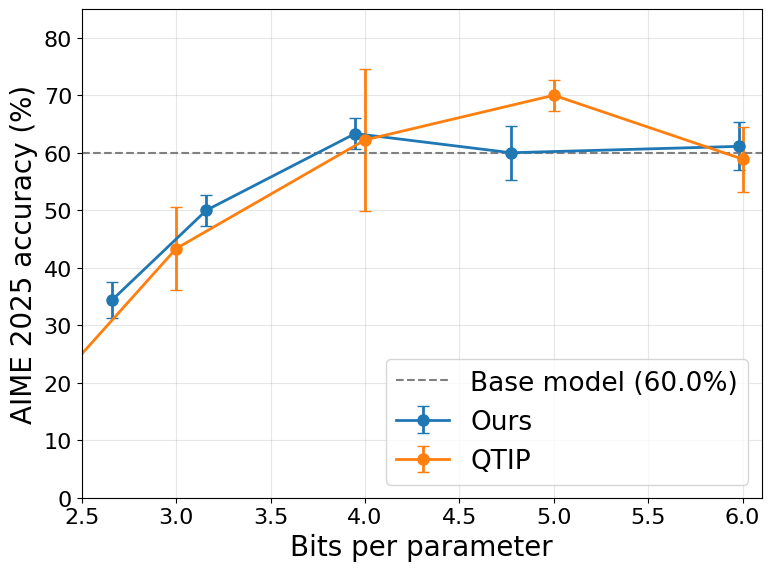

  saved plots_figures/Qwen3-4B_GPQA_Diamond.pdf


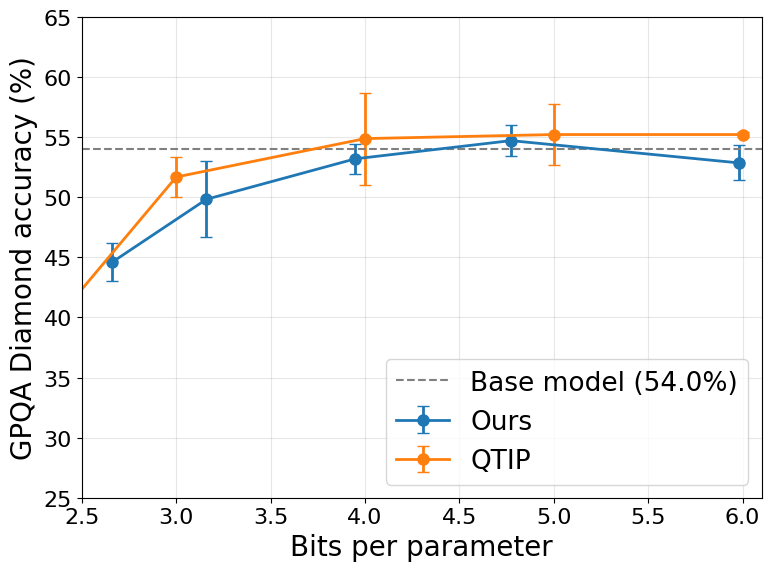

  saved plots_figures/Qwen3-4B_reasoning_avg.pdf


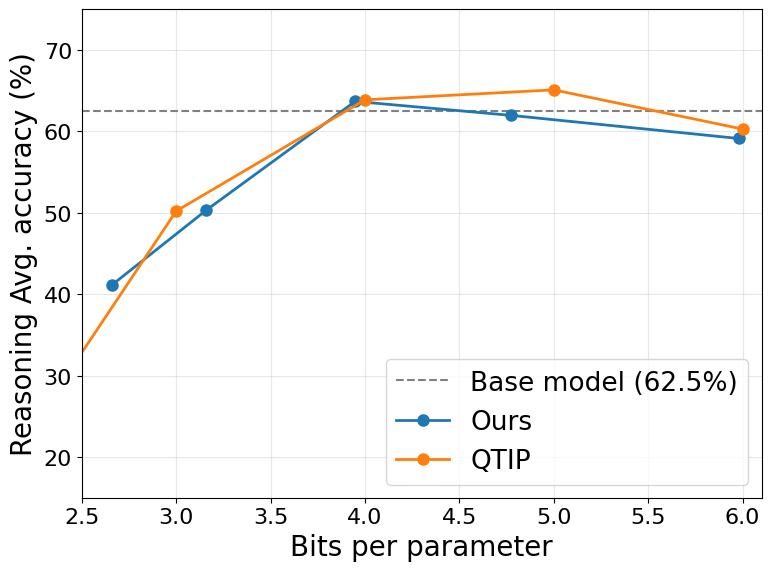

  saved plots_figures/Qwen3-4B_MMLU_PRO.pdf


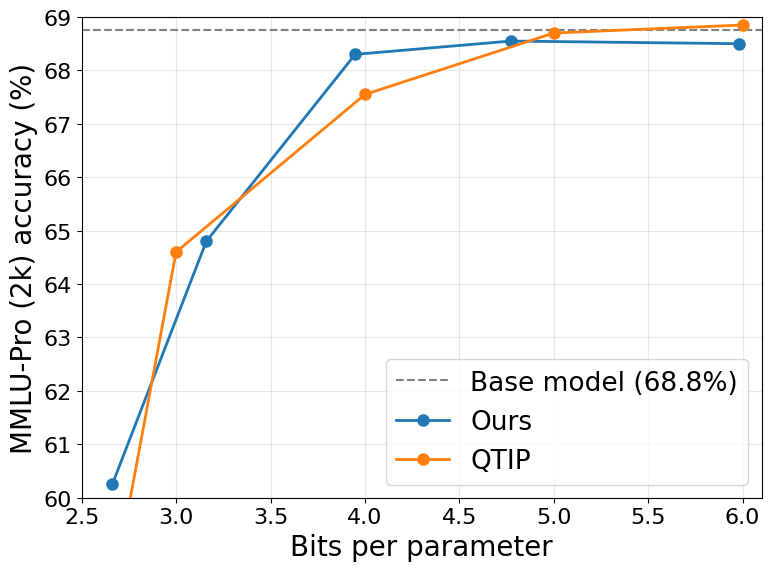

  saved plots_figures/Qwen3-4B_LongBench_V1.pdf


/tmp/ipykernel_1297034/3277205135.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


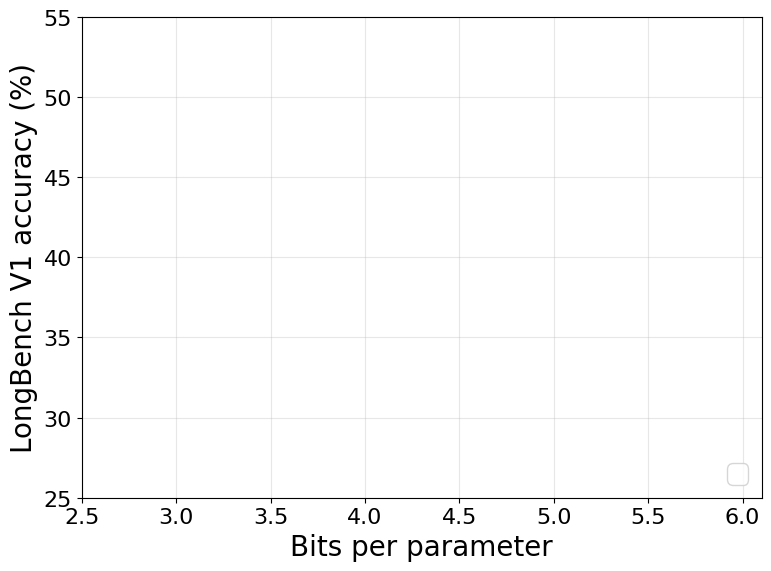

  saved plots_figures/Qwen3-8B_AIME_2024.pdf


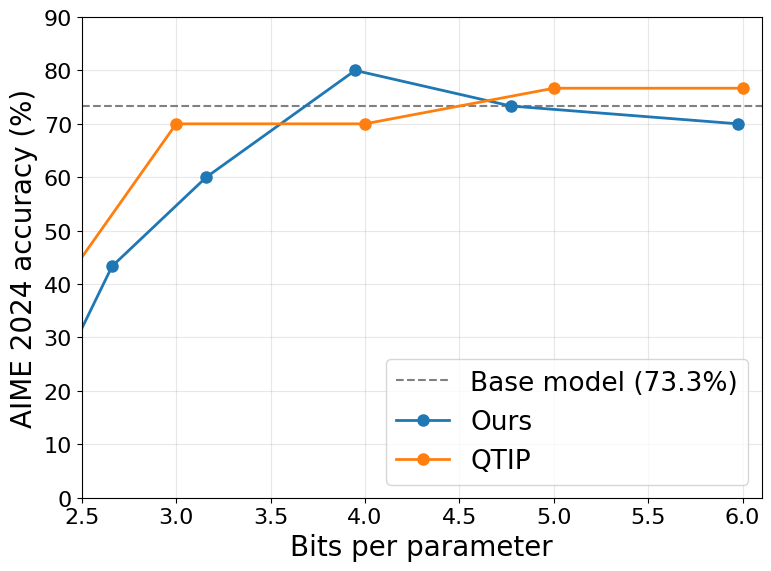

  saved plots_figures/Qwen3-8B_AIME_2025.pdf


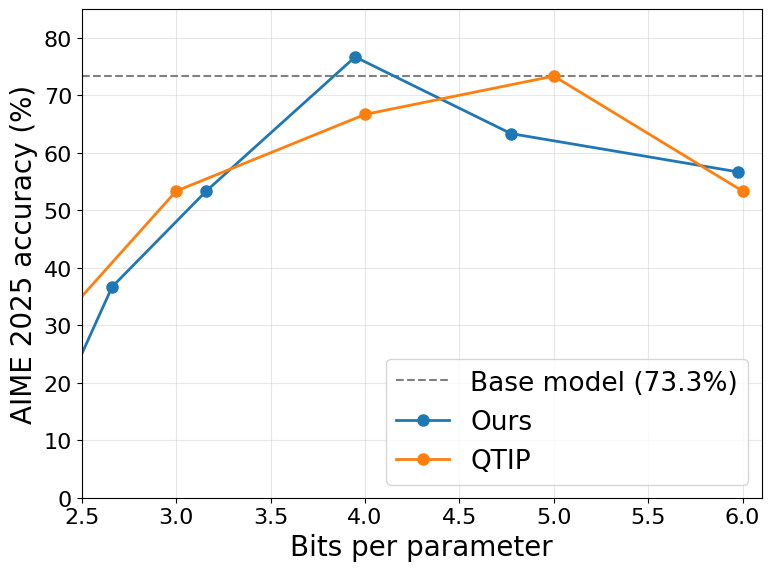

  saved plots_figures/Qwen3-8B_GPQA_Diamond.pdf


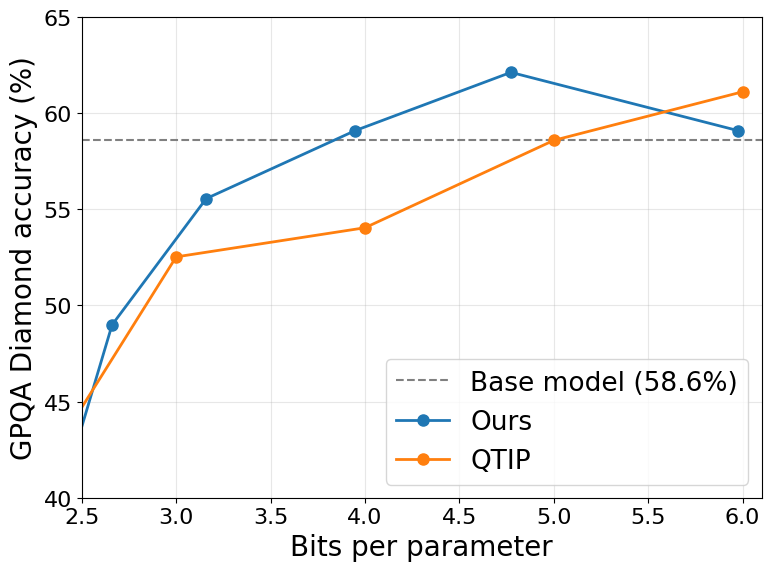

  saved plots_figures/Qwen3-8B_reasoning_avg.pdf


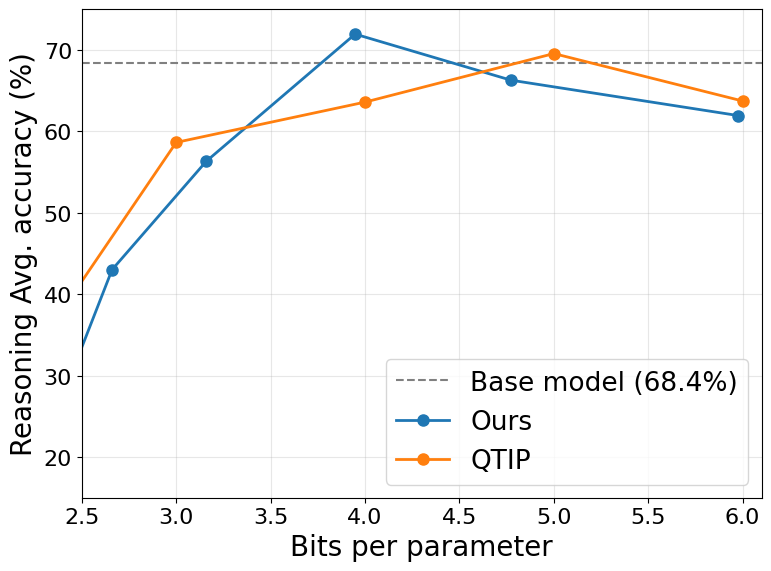

  saved plots_figures/Qwen3-8B_MMLU_PRO.pdf


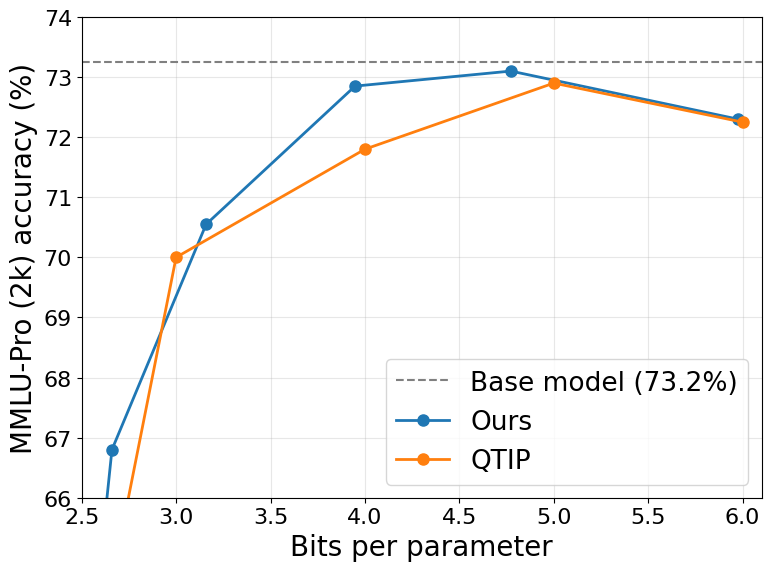

  saved plots_figures/Qwen3-8B_LongBench_V1.pdf


/tmp/ipykernel_1297034/3277205135.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


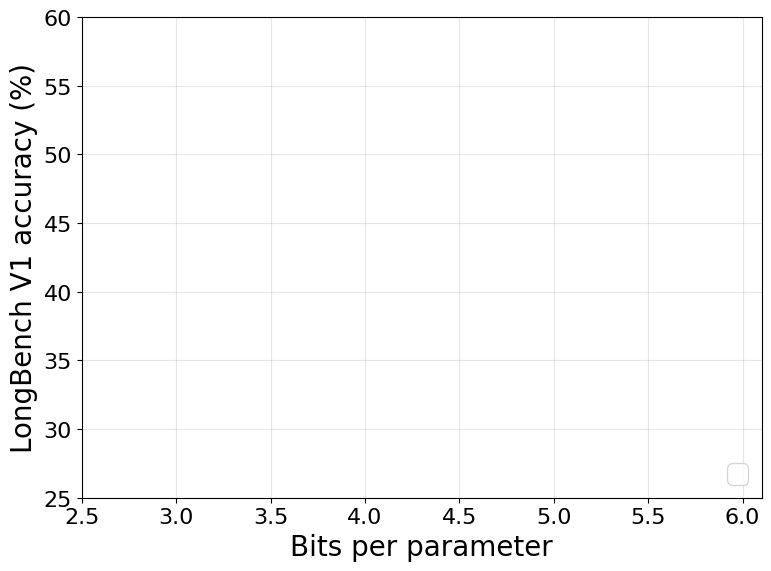

In [17]:
ylim_settings = {
    'Qwen3-4B': {
        'AIME-2024': (0, 95),
        'AIME-2025': (0, 85),
        'GPQA-Diamond': (25, 65),
        'reasoning_avg': (15, 75),
        'MMLU-PRO': (60, 69),
        'LongBench-V1': (25, 55),
    },
    'Qwen3-8B': {
        'AIME-2024': (0, 90),
        'AIME-2025': (0, 85),
        'GPQA-Diamond': (40, 65),
        'reasoning_avg': (15, 75),
        'MMLU-PRO': (66, 74),
        'LongBench-V1': (25, 60),
    },
}
zoom_ranges = {
    'AIME-2024': (2.5, 6.1),
    'AIME-2025': (2.5, 6.1),
    'GPQA-Diamond': (2.5, 6.1),
    'reasoning_avg': (2.5, 6.1),
    'MMLU-PRO': (2.5, 6.1),
    'LongBench-V1': (2.5, 6.1),
}
# zoom_ranges = {
#     'AIME-2024': (1.8, 7.0),
#     'AIME-2025': (1.8, 7.0),
#     'GPQA-Diamond': (1.8, 7.0),
#     'reasoning_avg': (1.8, 7.0),
#     'MMLU-PRO': (1.8, 7.0),
#     'LongBench-V1': (1.8, 7.0),
# }

plot_reasoning_bpp(
    df_master=df,
    exp_names=['Ours', 'QTIP'],
    models=['Qwen3-4B', 'Qwen3-8B'],
    plot_labels=['Ours', 'QTIP'],
    zoom_ranges=zoom_ranges,
    ylim_settings=ylim_settings,
    show_legend=True,
    save=True,
)

## Per-method per-task table

In [15]:
show_cols = ['bpp', 'AIME-2024', 'AIME-2024_std', 'AIME-2025', 'AIME-2025_std',
             'GPQA-Diamond', 'GPQA-Diamond_std', 'reasoning_avg', 'n_seeds', 'seeds']
summary = df.copy()
for c in ('AIME-2024', 'AIME-2025', 'GPQA-Diamond', 'reasoning_avg',
          'AIME-2024_std', 'AIME-2025_std', 'GPQA-Diamond_std'):
    if c in summary.columns:
        summary[c] = (summary[c].astype(float) * 100).round(2)
summary = summary[['Model', 'Experiment', 'tag', 'key'] + [c for c in show_cols if c in summary.columns]]
summary

,Model,Experiment,tag,key,bpp,AIME-2024,AIME-2024_std,AIME-2025,AIME-2025_std,GPQA-Diamond,GPQA-Diamond_std,reasoning_avg,n_seeds,seeds
0,Qwen3-4B,Base model,baseline,BF16,16.000000,73.33,0.00,60.00,0.00,54.04,0.00,62.46,1,seed42
1,Qwen3-4B,Ours,lmbda50,50.0,2.662192,44.44,4.16,34.44,3.14,44.61,1.56,41.17,3,"seed42,seed43,seed44"
2,Qwen3-4B,Ours,lmbda100,100.0,3.160042,51.11,4.16,50.00,2.72,49.83,3.15,50.31,3,"seed42,seed43,seed44"
3,Qwen3-4B,Ours,lmbda300,300.0,3.948022,74.44,1.57,63.33,2.72,53.20,1.26,63.66,3,"seed42,seed43,seed44"
4,Qwen3-4B,Ours,lmbda1000,1000.0,4.772930,71.11,4.16,60.00,4.71,54.71,1.26,61.94,3,"seed42,seed43,seed44"
5,Qwen3-4B,Ours,lmbda10000,10000.0,5.979113,63.33,2.72,61.11,4.16,52.86,1.45,59.10,3,"seed42,seed43,seed44"
6,Qwen3-4B,Ours,lmbda30,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,seed42
7,Qwen3-4B,QTIP,2bit,2,2.000000,6.67,2.72,6.67,2.72,33.00,2.75,15.44,3,"seed42,seed43,seed44"
8,Qwen3-4B,QTIP,3bit,3,3.000000,55.56,5.67,43.33,7.20,51.68,1.67,50.19,3,"seed42,seed43,seed44"
9,Qwen3-4B,QTIP,4bit,4,4.000000,74.44,4.16,62.22,12.27,54.88,3.83,63.85,3,"seed42,seed43,seed44"
